## Extracted a 2D projection of Apoferritin

In [1]:
import h5py
from matplotlib import pyplot as plt
import numpy as np

f = h5py.File(
    "/Users/bryce.shirley/Library/CloudStorage/OneDrive-ScienceandTechnologyFacilitiesCouncil/Documents/ptychobench/data/apo_potential_1nmSlice_101slice.mat"
)

data = f["apo_projected_potential"]

# Min/Max Value
print(f"Max Value: {np.max(data)}")
print(f"Mean Value: {np.mean(data)}")
print(f"Min Value: {np.min(data)}")

Max Value: 855.2108764648438
Mean Value: 42.06468200683594
Min Value: -5.733631134033203


In [2]:
wavelength_nm = 0.00197  # 300kV electron wavelength in nm
dz_nm = 1.0  # Slice thickness in nm
n_bg = 1.0  # Background index (vacuum)

# Calculate wavenumber (units: nm^-1)
k0_nm = (2 * np.pi) / wavelength_nm


ice_phase = np.median(data) / 1000.0
relative_phase = data - ice_phase

phi_max = np.max(relative_phase) / 1000.0
phi_min = np.min(relative_phase) / 1000.0


# Convert to refractive index range
n_max = n_bg + (phi_max / (k0_nm * dz_nm))
n_min = n_bg + (phi_min / (k0_nm * dz_nm))


print(f"Global Phase Offset (Ice): {ice_phase:.4f} rad")
print(f"True Physical Phase Range: {phi_min:.4f} to {phi_max:.4f} rad")
print(f"Refractive Index Range:    {n_min:.8f} to {n_max:.8f}")

Global Phase Offset (Ice): 0.0250 rad
True Physical Phase Range: -0.0058 to 0.8552 rad
Refractive Index Range:    0.99999821 to 1.00026810


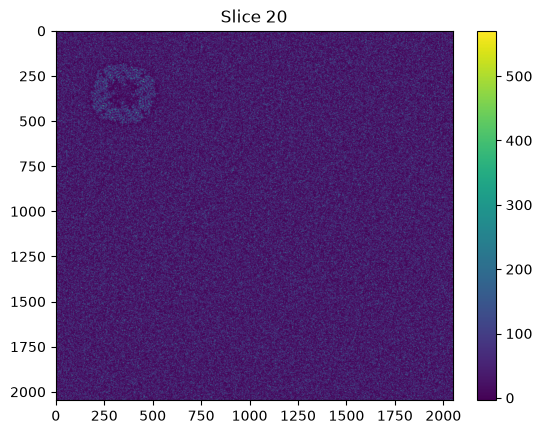

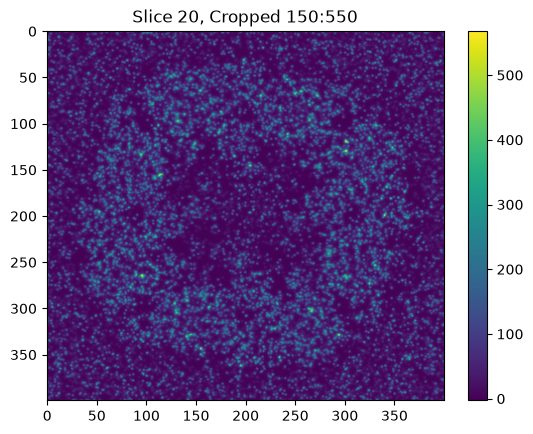

In [3]:
plt.imshow(data[20, :, :], aspect="auto")
plt.title("Slice 20")
plt.colorbar()
plt.show()
# for i in range(250, 350, 25):
#     plt.imshow(data[:,i,150:550], aspect='auto')
#     plt.title(f'Slice {i}')
#     plt.show()

cropped_data = data[:, 150:550, 150:550]
plt.imshow(cropped_data[20, :, :], aspect="auto")
plt.colorbar()
plt.title("Slice 20, Cropped 150:550")
plt.show()

(101, 400, 400)
(100, 400)


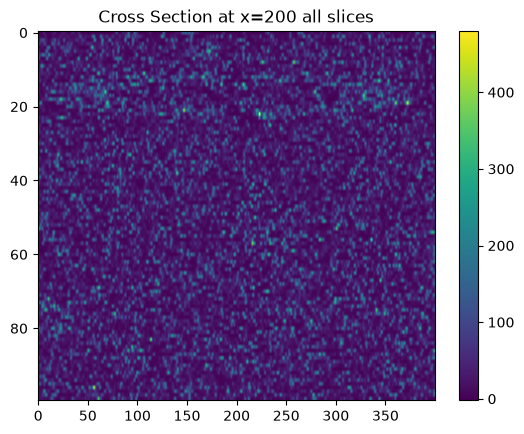

In [4]:
print(cropped_data.shape)
cross_section = cropped_data[:100, :, 200]
print(cross_section.shape)
plt.imshow(cross_section, aspect="auto")
plt.title("Cross Section at x=200 all slices")
plt.colorbar()
plt.show()

In [5]:
# np.save(f'./src/ptychobench/apoferritin_{cross_section.shape[0]}Nz{cross_section.shape[1]}Nx',cross_section)